In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import zipfile
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision.transforms.functional import to_pil_image
from torchvision import transforms
from collections import defaultdict
import kagglehub
import segmentation_models_pytorch as smp

C:\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch version: 2.5.0+cu124
CUDA available: True
CUDA version: 12.4
Number of GPUs: 2
GPU 0: NVIDIA GeForce RTX 4090
GPU 1: NVIDIA GeForce RTX 4090


In [3]:
torch.cuda.set_device(1)
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: NVIDIA GeForce RTX 4090


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
path = kagglehub.dataset_download("rajkumarl/people-clothing-segmentation")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\n.sedov\.cache\kagglehub\datasets\rajkumarl\people-clothing-segmentation\versions\2


In [6]:
image_dir = 'png_images/IMAGES'
mask_dir = 'png_masks/MASKS'
num_classes=59

In [7]:
import os
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class ClothesSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, image_transform=None, mask_transform=None, shared_transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.shared_transform = shared_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Загружаем изображение и маску
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Применяем общие аугментации
        if self.shared_transform:
            augmented = self.shared_transform(image=np.array(image), mask=np.array(mask))
            image = augmented['image']
            mask = augmented['mask']

        # Применяем аугментации для изображения
        if self.image_transform:
            augmented = self.image_transform(image=image)
            image = augmented['image']
        else:
            image = ToTensorV2()(image)

        # Применяем аугментации для маски
        if self.mask_transform:
            augmented = self.mask_transform(mask=mask)
            mask = augmented['mask']
            mask = torch.tensor(np.array(mask), dtype=torch.uint8).unsqueeze(0)
        else:
            mask = torch.tensor(np.array(mask), dtype=torch.uint8).unsqueeze(0)

        return image, mask


image_dir = 'png_images/IMAGES'
mask_dir = 'png_masks/MASKS'

image_files = sorted([f for f in os.listdir(image_dir)])
mask_files = sorted([f for f in os.listdir(mask_dir)])

image_paths = [os.path.join(image_dir, f) for f in image_files]
mask_paths = [os.path.join(mask_dir, f) for f in mask_files]

train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)

size=512
shared_transform_train = A.Compose(
    [
        A.Resize(width=size, height=size, interpolation=0, p=1),
        A.HorizontalFlip(p=1/3),
        A.VerticalFlip(p=1/3),
        A.Rotate(limit=300, p=1, border_mode=0),])


train_transform_image = A.Compose(
    [
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),])

val_transform_image = A.Compose(
    [
        A.Resize(width=size, height=size, interpolation=0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),])

shared_transform_val=A.Compose([A.Resize(width=size, height=size, interpolation=0),])

train_dataset = ClothesSegmentationDataset(
    image_paths=train_image_paths,
    mask_paths=train_mask_paths,
    image_transform=train_transform_image,
    mask_transform=None,
    shared_transform=shared_transform_train,
)

val_dataset = ClothesSegmentationDataset(
    image_paths=val_image_paths,
    mask_paths=val_mask_paths,
    image_transform=val_transform_image,
    mask_transform=None,
    shared_transform=shared_transform_val,
)

train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False)


C:\Python310\lib\site-packages\albumentations\check_version.py:51: UserWarning: Error fetching version info <urlopen error _ssl.c:990: The handshake operation timed out>
  data = fetch_version_info()


In [8]:
from collections import Counter
def count_class_pixels(mask_dir):
    class_counts = Counter()
    mask_files = sorted(os.listdir(mask_dir))
    
    for mask_file in mask_files:
        mask_path = os.path.join(mask_dir, mask_file)
        mask = np.array(Image.open(mask_path))
        for class_id in range(num_classes):
            class_counts[class_id] += np.sum(mask == class_id)
    
    return class_counts
class_counts=count_class_pixels(mask_dir)
total_pixels = sum(class_counts.values())
class_weights={id:value/total_pixels for id, value in class_counts.items()}
class_weights2={id:1/value if value!=0 else 0 for id, value in class_weights.items()}
weights = np.array(list(class_weights2.values()))
normalized_weights = weights / np.sum(weights)

In [9]:
for batch_idx, (images, masks) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    print(f"Images shape: {images.shape}")
    print(f"Masks shape: {masks.shape}")
    first_image = images[0]
    first_mask = masks[0]
    break


Batch 1:
Images shape: torch.Size([6, 3, 512, 512])
Masks shape: torch.Size([6, 1, 512, 512])


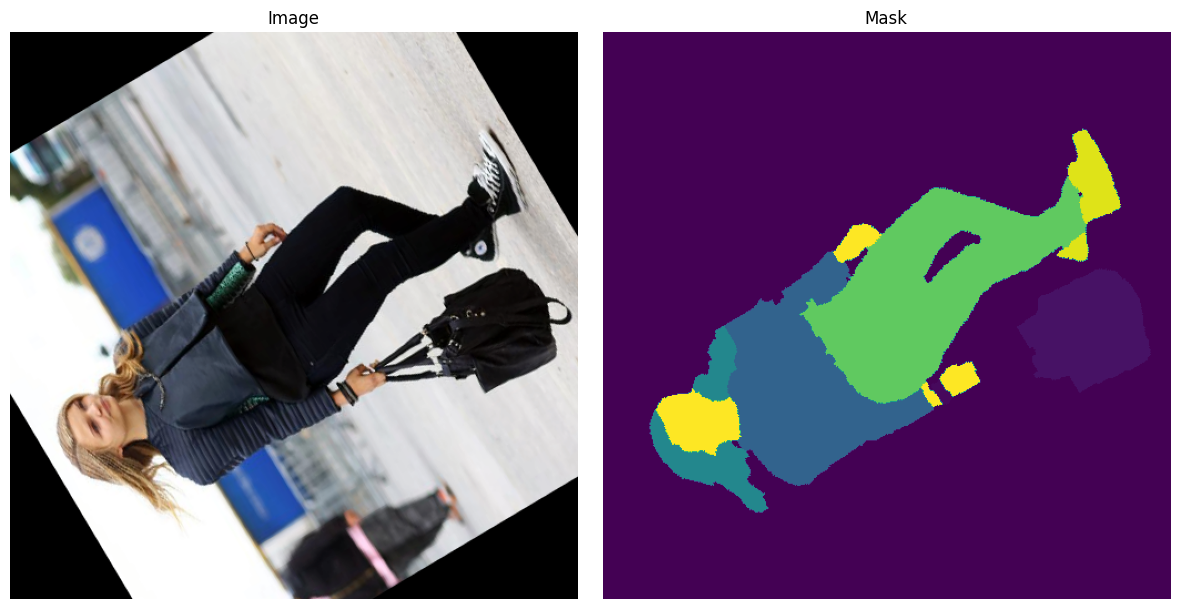

In [10]:
import torch
import numpy as np
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import matplotlib.pyplot as plt


def denormalize(image, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1).to(image.device)
    std = torch.tensor(std).view(3, 1, 1).to(image.device)
    return image * std + mean


def show_image_with_mask(image, mask):
    image = denormalize(image, mean, std).clamp(0, 1)
    image = to_pil_image(image)
    if isinstance(mask, torch.Tensor):
        if mask.dim() == 3 and mask.size(0) == 1:
            mask = mask.squeeze(0)
        mask = mask.cpu().numpy().astype('uint8')
    elif isinstance(mask, np.ndarray):
        if mask.ndim == 3 and mask.shape[0] == 1:
            mask = np.squeeze(mask, axis=0)
        mask = mask.astype('uint8')
    else:
        raise TypeError("Mask must be a PyTorch tensor or NumPy array")

    mask_image = Image.fromarray(mask)
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(image)
    ax[0].set_title("Image")
    ax[0].axis("off")

    ax[1].imshow(mask_image)
    ax[1].set_title("Mask")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

image, mask = train_dataset[0]
show_image_with_mask(image, mask)


In [11]:
import torch
import numpy as np
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import matplotlib.pyplot as plt

def show_image_mask_prediction(image, mask, predicted_mask, mean, std,epoch=None):
    image = denormalize(image, mean, std).clamp(0, 1)

    image = to_pil_image(image)

    def process_mask(mask):
        if isinstance(mask, torch.Tensor):
            if mask.dim() == 3 and mask.size(0) == 1:
                mask = mask.squeeze(0)
            mask = mask.cpu().numpy().astype('uint8')
        elif isinstance(mask, np.ndarray):
            if mask.ndim == 3 and mask.shape[0] == 1:
                mask = np.squeeze(mask, axis=0)
            mask = mask.astype('uint8')
        else:
            raise TypeError("Mask must be a PyTorch tensor or NumPy array")
        return mask

    mask = process_mask(mask)
    predicted_mask = process_mask(predicted_mask)

    mask_image = Image.fromarray(mask)
    predicted_mask_image = Image.fromarray(predicted_mask)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(image)
    ax[0].set_title("Image")
    ax[0].axis("off")

    ax[1].imshow(mask_image)
    ax[1].set_title("Ground Truth Mask")
    ax[1].axis("off")

    ax[2].imshow(predicted_mask_image)
    ax[2].set_title("Predicted Mask")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()
    if epoch is not None:
        plt.savefig(f'image_at_{epoch}.png', bbox_inches='tight', pad_inches=0)

In [12]:
class Unet(nn.Module):
    def __init__(self, in_channels, out_classes=59):
        super(Unet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout(0.25),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.enc5 = conv_block(512, 1024)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_classes, kernel_size=1) # слой предсказания

    def forward(self, x):
        # encoder
        e1 = self.enc1(x)  # 64
        p1 = self.pool(e1)  # Пуллинг

        e2 = self.enc2(p1)  # 128
        p2 = self.pool(e2)

        e3 = self.enc3(p2)  # 256
        p3 = self.pool(e3)

        e4 = self.enc4(p3)  # 512
        p4 = self.pool(e4)

        e5 = self.enc5(p4)  # 1024

        # decoder
        u4 = self.up4(e5)  # Транспонированная свертка
        d4 = self.dec4(torch.cat([u4, e4], dim=1))  # skip connection

        u3 = self.up3(d4)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.final(d1)
        return out

In [18]:
import torch
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR

# Параметры
num_epochs = 10
learning_rate = 3e-4
# Инициализация модели
model = Unet(in_channels=3, out_classes=59) 
model.to(device)

# Функция потерь
criterion = smp.losses.DiceLoss(mode='multiclass')

# Оптимизатор
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [19]:
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("-" * 20)
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    for inputs, targets in tqdm(train_loader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)


        targets = targets.long() 
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        tp, fp, fn, tn = smp.metrics.get_stats(predictions, targets.squeeze(1), mode="multiclass", num_classes=num_classes)
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="weighted",class_weights=normalized_weights)
        train_iou += iou.item()

    train_loss /= len(train_loader)
    train_iou /= len(train_loader)

    print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc="Validation"):
            targets = targets.squeeze(1)

            targets = targets.long()
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            tp, fp, fn, tn = smp.metrics.get_stats(predictions, targets, mode="multiclass", num_classes=num_classes)
            iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="weighted",class_weights=normalized_weights)
            val_iou += iou.item()

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    print(f"Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr:.6f}")


Epoch 1/10
--------------------


Training: 100%|██████████| 134/134 [00:41<00:00,  3.21it/s]


Train Loss: 0.3497 | Train IoU: 0.5121


Validation: 100%|██████████| 34/34 [00:05<00:00,  6.60it/s]


Val Loss: 0.3447 | Val IoU: 0.8030
Current Learning Rate: 0.000300
Epoch 2/10
--------------------


...

Val Loss: 0.3170 | Val IoU: 0.9587
Current Learning Rate: 0.000300
Epoch 10/10
--------------------


Training: 100%|██████████| 134/134 [00:41<00:00,  3.24it/s]


Train Loss: 0.2940 | Train IoU: 0.9641


Validation: 100%|██████████| 34/34 [00:05<00:00,  6.62it/s]

Val Loss: 0.3097 | Val IoU: 0.9581
Current Learning Rate: 0.000300


In [18]:
torch.cuda.empty_cache()

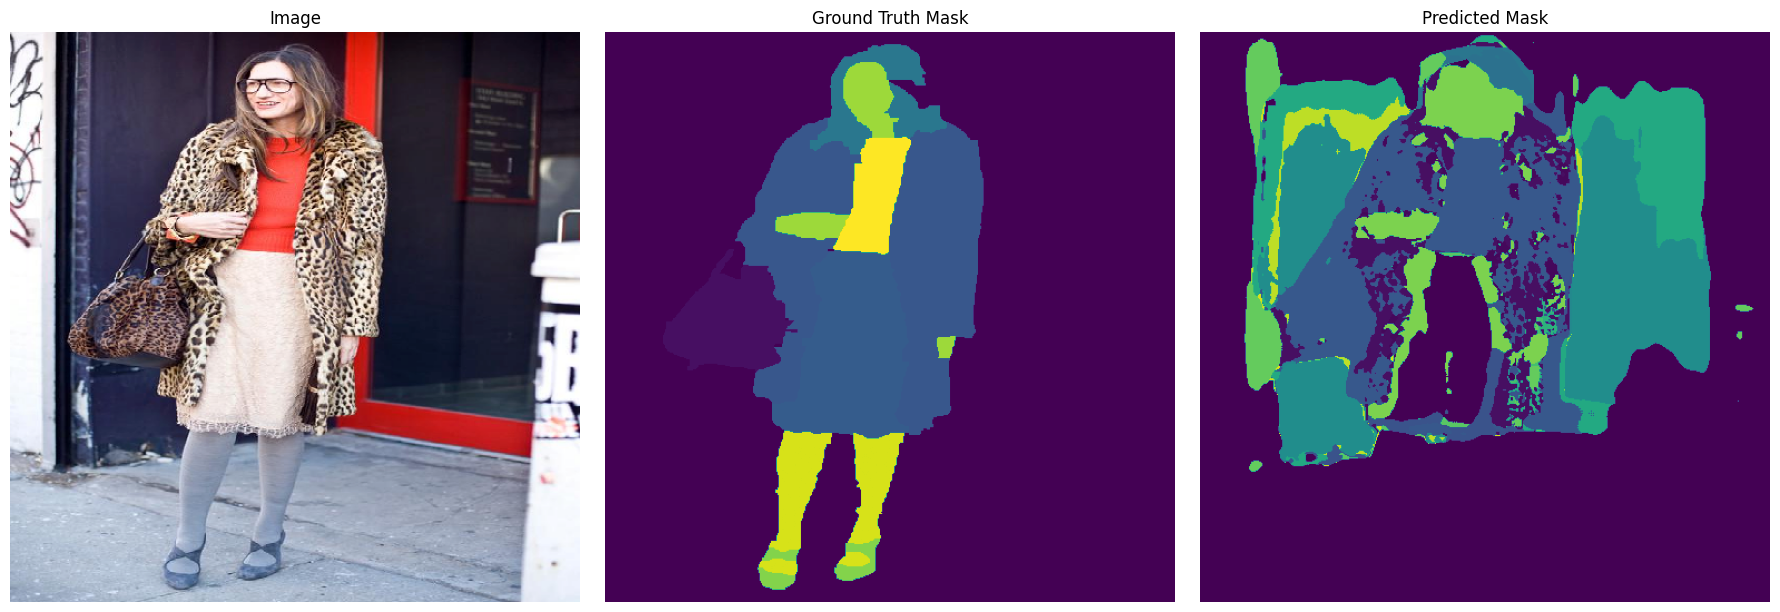

In [20]:
import random
model.eval()
image,mask=val_dataset[random.choice(range(200))]
image=image.unsqueeze(0)
mask=mask
with torch.no_grad():
    image=image.to(device)
    output = model(image)
output = torch.softmax(output, dim=1)
predicted_mask = torch.argmax(output, dim=1)
show_image_mask_prediction(image.squeeze(0), mask, predicted_mask, mean, std)

In [21]:
import torch
from torch.utils.data import DataLoader
from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor, AdamW
import torch.nn.functional as F
import segmentation_models_pytorch as smp
from tqdm import tqdm


model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
model_1 = SegformerForSemanticSegmentation.from_pretrained(model_name).to(device)
feature_extractor_1 = SegformerFeatureExtractor.from_pretrained(model_name)

optimizer_1 = AdamW(model_1.parameters(), lr=1e-4)
criterion_1 = smp.losses.DiceLoss(mode='multiclass')


num_classes = 59


normalized_weights_1 = torch.tensor(normalized_weights).to(device)  

epochs = 5  
for epoch in range(epochs):
    model_1.train()
    train_loss_1 = 0
    train_iou_1 = 0
    num_train_batches_1 = 0
    

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{epochs}"):
        images, masks = batch
        images = images.to(device)
        masks = masks.to(device)
        

        masks = masks.squeeze(1)  
        
        masks = masks.long() 


        masks = F.interpolate(masks.unsqueeze(1).float(), size=(128, 128), mode='nearest').squeeze(1).long()

        optimizer_1.zero_grad()


        outputs_1 = model_1(images, labels=masks)
        loss_1 = outputs_1.loss
        logits_1 = outputs_1.logits

        loss_1.backward()
        optimizer_1.step()

        predictions_1 = torch.argmax(logits_1, dim=1)

        tp_1, fp_1, fn_1, tn_1 = smp.metrics.get_stats(predictions_1, masks, mode="multiclass", num_classes=num_classes)
        
        iou_1 = smp.metrics.iou_score(tp_1, fp_1, fn_1, tn_1, reduction="weighted", class_weights=normalized_weights_1)
        
        train_loss_1 += loss_1.item()
        train_iou_1 += iou_1.item()
        num_train_batches_1 += 1
    
    avg_train_loss_1 = train_loss_1 / num_train_batches_1
    avg_train_iou_1 = train_iou_1 / num_train_batches_1
    
    print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {avg_train_loss_1:.4f} - Train IoU: {avg_train_iou_1:.4f}")
    
    # Валидация
    model_1.eval()
    val_loss_1 = 0
    val_iou_1 = 0
    num_val_batches_1 = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Validating Epoch {epoch + 1}/{epochs}"):
            images, masks = batch
            images = images.to(device)
            masks = masks.to(device)

            masks = masks.squeeze(1) 

            masks = masks.long()  

            masks = F.interpolate(masks.unsqueeze(1).float(), size=(128, 128), mode='nearest').squeeze(1).long()

            outputs_1 = model_1(images, labels=masks)
            loss_1 = outputs_1.loss
            logits_1 = outputs_1.logits

            predictions_1 = torch.argmax(logits_1, dim=1)

            tp_1, fp_1, fn_1, tn_1 = smp.metrics.get_stats(predictions_1, masks, mode="multiclass", num_classes=num_classes)
            
            iou_1 = smp.metrics.iou_score(tp_1, fp_1, fn_1, tn_1, reduction="weighted", class_weights=normalized_weights_1)
            
            val_loss_1 += loss_1.item()
            val_iou_1 += iou_1.item()
            num_val_batches_1 += 1
    
    avg_val_loss_1 = val_loss_1 / num_val_batches_1
    avg_val_iou_1 = val_iou_1 / num_val_batches_1
    
    print(f"Epoch {epoch + 1}/{epochs} - Val Loss: {avg_val_loss_1:.4f} - Val IoU: {avg_val_iou_1:.4f}")



===================================BUG REPORT===================================
The following directories listed in your path were found to be non-existent: {WindowsPath('C:/Program Files (x86)/Microsoft SQL Server/160/DTS/Binn'), WindowsPath('C:/Python310/Lib/site-packages/cv2/../../x64/vc14/bin')}
The following directories listed in your path were found to be non-existent: {WindowsPath('/DC2')}
The following directories listed in your path were found to be non-existent: {WindowsPath('DL/06_2_image_segmentation.ipynb')}
The following directories listed in your path were found to be non-existent: {WindowsPath('module:/matplotlib_inline.backend_inline')}
CUDA_SETUP: WARNING! ['cudart64_110.dll', 'cudart64_120.dll', 'cudart64_12.dll'] not found in any environmental path. Searching in backup paths...
DEBUG: Possible options found for libcudart.so: set()
CUDA SETUP: PyTorch settings found: CUDA_VERSION=124, Highest Compute Capability: 8.9.
CUDA SETUP: To manually override the PyTorch CUD

RuntimeError: Failed to import transformers.models.segformer.modeling_segformer because of the following error (look up to see its traceback):

        CUDA Setup failed despite GPU being available. Please run the following command to get more information:

        python -m bitsandbytes

        Inspect the output of the command and see if you can locate CUDA libraries. You might need to add them
        to your LD_LIBRARY_PATH. If you suspect a bug, please take the information from python -m bitsandbytes
        and open an issue at: https://github.com/TimDettmers/bitsandbytes/issues

In [17]:
import random

model_1.eval()

image, mask = val_dataset[random.choice(range(200))]
image = image.unsqueeze(0)

with torch.no_grad():
    image = image.to(device)
    output = model_1(image)
logits = output.logits
output_probabilities = torch.softmax(logits, dim=1)
predicted_mask = torch.argmax(output_probabilities, dim=1)
show_image_mask_prediction(image.squeeze(0), mask, predicted_mask, mean, std)


NameError: name 'model_1' is not defined